# FR-MF - Rainfall rate over France mainland

### Description

This notebook describes how to access and use the zarr-version of the French radar data provided by [Météo-France](https://meteofrance.com/). 
The dataset includes aproximately ~500.000 5 min timesteps covering a 1536 x 1536 resolution with 1km grid-size. The original radar.npz files are stored in (mm x 10^-2) and the .zarr dataset is in precipitation rate (mm/h).

### Related repositories
- The conversion of the radar data was done by the code hosted on [https://github.com/mlcast-community/mlcast-dataset-FR-MF](https://github.com/mlcast-community/mlcast-dataset-FR-MF).

- The radar dataset can be directly downloaded from Météo-France [Hugging Face](https://huggingface.co/datasets/meteofrance/fr-radar-rainfall/tree/main) repository.

The `v0.1.0` zarr dataset covers the temporal period of `2020-01-01` to `2024-12-31`.

### Citation

Data provided by Météo-France. Processed and distributed by Météo-France AI Lab for open research and development purposes.
Please cite as:
```tex
@misc{radar_rainfall_france,
  title        = {5 Minutes Radar Rainfall over French Mainland Territory},
  author       = {Météo-France},
  year         = {2025},
  howpublished = {\url{https://huggingface.co/datasets/meteofrance/radar-rainfall}},
  note         = {Distributed under Etalab 2.0 License}
}
```

Licence: [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/)



In [1]:
import matplotlib.pyplot as plt
import xarray as xr

import cartopy.feature as cfeature
import cartopy.crs as ccrs
import mlcast_datasets

In [2]:
cat = mlcast_datasets.open_catalog()
list(cat.precipitation)

['radklim_hourly',
 'radklim_5_minutes',
 'dmi_10_minutes',
 'it_dpc_sri_5min',
 'uk_metoffice_5min',
 'be_rmi_radclim_mfb_5min',
 'fr_mf_prate_5min']

# FR-MF - 5-min Rainfall rate

The French MF SRI dataset is available in the intake catalog as `fr_mf_prate_5min`.

In [3]:
ds = cat.precipitation.fr_mf_prate_5min.to_dask()
ds

<xarray.Dataset> Size: 5TB
Dimensions:        (time: 525787, y: 1536, x: 1536, missing_times: 389)
Coordinates:
  * time           (time) datetime64[ns] 4MB 2020-01-01 ... 2024-12-31T23:55:00
  * y              (y) float64 12kB -3.527e+06 -3.528e+06 ... -5.062e+06
  * x              (x) float64 12kB -6.197e+05 -6.187e+05 ... 9.153e+05
    lat            (y, x) float64 19MB dask.array<chunksize=(1536, 1536), meta=np.ndarray>
    lon            (y, x) float64 19MB dask.array<chunksize=(1536, 1536), meta=np.ndarray>
  * missing_times  (missing_times) datetime64[m] 3kB 2020-01-27T07:45:00 ... ...
Data variables:
    crs            float64 8B ...
    prate          (time, y, x) float32 5TB dask.array<chunksize=(1, 1536, 1536), meta=np.ndarray>
Attributes: (12/13)
    Author:                     Météo-France
    Copyright:                  Météo-France
    Processed by:               WebValley2026, Fondazione Bruno Kessler
    base_frequencies:           5min:2020-01-01T00:00/2024-12-31T23:55
    consistent_timestep_start:  2020-01-01T00:00
    history:                    Created at 2026-06-29T19:00:00+01:00
    ...                         ...
    mlcast_created_by:          WebValley2026, Fondazione Bruno Kessler, <web...
    mlcast_created_on:          2026-06-29T19:00:00+01:00
    mlcast_dataset_identifier:  FR-MF-prate
    mlcast_dataset_version:     0.1.0
    title:                      Météo-France Radar Rainfall Archive
    mlcast_created_with:        https://github.com/mlcast-community/mlcast-da...

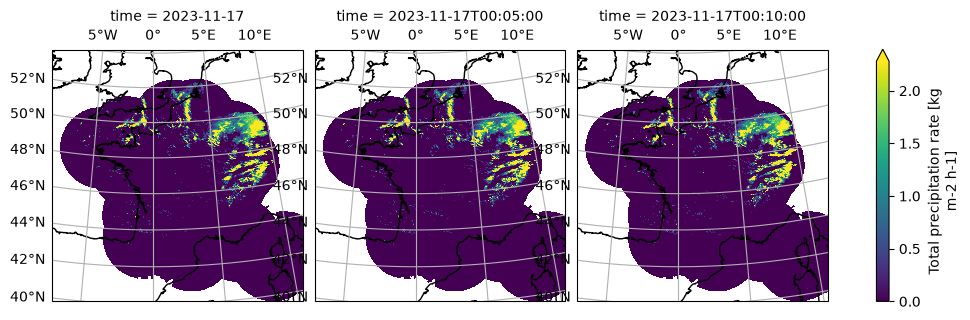

In [4]:
var_name = "prate"
crs_name = ds[var_name].grid_mapping
data_crs = ccrs.Projection(ds[crs_name].crs_wkt)

g = (
    ds[var_name]
    .sel(time="2023-11-17")
    .isel(time=slice(None, 3))
    .plot(
        transform=data_crs,
        cmap="viridis",
        add_colorbar=True,
        col="time",
        robust=True,
        subplot_kws=dict(projection=data_crs),
        vmin=0,
    )
)

for ax in g.axes.flat:
    ax.coastlines()
    ax.gridlines(draw_labels=["top", "left"])